# 1. Setup

### Imports

In [1]:
# reload new modules automatically
%load_ext autoreload
%autoreload 2

In [2]:
import math
import sys
import os
import subprocess
import sys
import time
import json

from datetime import datetime, timezone
from pathlib import Path
from threading import Thread
from argparse import Namespace

try:
    from egrabber import *
except:
    print('Egrabber not found, continuing without it.')

import numpy as np
import cv2
import ctypes
import modal
import sounddevice as sd
import matplotlib.pyplot as plt

from PIL import Image
from scipy.signal import butter, filtfilt,resample
from scipy.io.wavfile import write
from pyueye import ueye

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import to_rgb

# Add parent directory to path for local imports
for p in (Path.cwd().parent, Path.cwd() / 'data'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

# local imports
from utils.recover_core_lib import *
from data.audio import main

from utils.ids_camera.pyueye_example_camera import Camera as PyueyeCamera
from utils.image_processing import adjustGamma
from utils.metrics import center_of_mass

from utils.viz import preview
from utils.io_utils import copy, load, append, copy_to_sample, save, load_metadata, to_jpeg_bytes, unpack_masks, symlink
from utils.helpers import Timing, print_system_usage, setup_logger, logger
from vibrate import capture_vibrations, save_vibrations, process_vibrations, process_vibrations_2, warmup_pclk
from audio import load_audio_artifacts
from image import save_overhead, process_overhead, make_overhead
from data.pclk import pclk

SWP_NOMOVE = 0x0002
SWP_NOSIZE = 0x0001
HWND_TOPMOST = -1

import traceback

import matplotlib.pyplot as plt

signal_crop = None
if 'run_opt' not in locals():
    run_opt = {}

if 'run_opt_recovery' not in locals():
    run_opt_recovery = {}

# enable interactive matplotlib plots
%matplotlib inline

FONT = cv2.FONT_HERSHEY_SIMPLEX

from IPython.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

### Laser Camera Parameters

In [4]:
# setup laser camera parameters
N_ROI_ROWS = 10 # rows
N_ROI_COLUMNS = 10 # columns
ROI_ROW_HEIGHT = 30 # row height
ROI_COLUMN_WIDTH = 70 # column width

# calibrate on a smaller ROI with lower FPS
CALIBRATION_FPS = 500
CALIBRATION_EXPOSURE = 60
CALIBRATION_GAIN = 1

FPS = 2_500
EXPOSURE = 60
GAIN = 1

BUFFER_PART_COUNT = 1625 # makes it faster to capture/send frames

### Overhead Camera Parameters

In [5]:
EXPOSURE_MS = 8        # Exposure time in milliseconds
FRAME_RATE = 30          # Target frame rate (FPS)
PIXEL_CLOCK = 86         # Pixel clock speed
CAMERA_GAIN = 0          # Camera gain (0-100) higher gain = brighter image
RESIZE_FACTOR = 0.75     # Preview resize factor for display
GAMMA = 2              # Gamma correction for preview

### Vibration Recording Parameters

In [6]:
AUDIO_DIR = Path(r'C:\Users\eitanturok\good-vibrations\data\audio\chirp_50_1000_3.0sec')

### Other Parameters

In [7]:
PREVIEW = 1 # set higher values for more debug info

In [8]:
RESET_ROIS = True  # Whether to reset ROIs or use previous ones

# 2. Setup Overhead Camera

In [9]:
def setup_camera(exposure_ms=3.0, frame_rate=30, pixel_clock=86, gain=0):
    """
    Initialize and configure IDS camera with specified parameters.

    Args:
        exposure_ms: Exposure time in milliseconds
        frame_rate: Target frame rate in FPS
        pixel_clock: Pixel clock speed
        gain: Camera gain (0-100)

    Returns:
        overhead_cam: Configured Camera object
        img_size: Tuple of (width, height)
    """

    # Check if cam exists in the local namespace and close it
    # Simply calling `del cam` will fail because Python's garbage collector doesn't necessarily close the hardware driver connection immediately, leaving the camera locked.
    global overhead_cam
    if 'overhead_cam' in locals() or 'overhead_cam' in globals():
        try:
            overhead_cam.exit()
            print("Closed existing camera connection.")
        except:
            pass

    # Initialize camera
    overhead_cam = PyueyeCamera(device_id=0)
    overhead_cam.init()
    overhead_cam.set_colormode(ueye.IS_CM_SENSOR_RAW8)
    overhead_cam.alloc(buffer_count=40)

    # Set camera parameters (set_frame_rate returns the actual frame rate)
    overhead_cam.set_pixel_clock(pixel_clock)
    overhead_cam.set_exposure(exposure_ms)
    overhead_cam.set_gain(gain)
    actual_fps = overhead_cam.set_frame_rate(frame_rate)

    # Get actual settings and image size
    actual_exposure = overhead_cam.get_exposure()
    actual_pixel_clock = overhead_cam.get_pixel_clock()
    actual_gain = overhead_cam.get_gain()
    img_w = overhead_cam.get_aoi().width
    img_h = overhead_cam.get_aoi().height

    print('===== Camera Setup =====')
    print(f'Image size: {img_w}x{img_h}')
    print(f'Exposure: {actual_exposure:.3f} ms')
    print(f'Frame rate: {actual_fps:.3f} FPS')
    print(f'Pixel clock: {actual_pixel_clock} MHz')
    print(f'Gain: {actual_gain}')

    return overhead_cam, (img_w, img_h)

In [10]:
def preview_image(overhead_cam, resize_factor=0.75, gamma=1.0):
    """
    Display live camera preview. Press Enter to exit.

    Args:
        overhead_cam: Camera object
        resize_factor: Scale factor for display (0-1)
        gamma: Gamma correction value
    """
    # Start video capture
    overhead_cam.disable_external_trigger()
    overhead_cam.capture_video()

    cv2.namedWindow("IDS Camera Preview")

    try:
        while True:
            # Capture raw frame
            raw_frame, _ = overhead_cam.read_frame()

            # Convert Bayer to BGR FIRST (before rotation to preserve Bayer pattern)
            frame = cv2.cvtColor(raw_frame.astype('uint8'), cv2.COLOR_BAYER_BG2BGR)

            # Rotate 180 degrees to fix camera orientation
            frame = cv2.rotate(frame, cv2.ROTATE_180)

            # Apply gamma correction (adjustGamma is imported at top)
            if gamma != 1.0:
                frame = adjustGamma(frame, gamma=gamma)

            # Resize for display
            if resize_factor != 1:
                frame = cv2.resize(frame, None, fx=resize_factor, fy=resize_factor)

            # Add info text
            cv2.putText(frame, 'Press Enter to exit', (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

            cv2.imshow("IDS Camera Preview", frame)

            # Exit on Enter key
            if cv2.waitKey(1) == 13:
                break

    finally:
        cv2.destroyAllWindows()
        overhead_cam.stop_video()

In [11]:
def capture_overhead(overhead_cam):
    # Start video capture mode
    overhead_cam.disable_external_trigger()
    overhead_cam.capture_video()

    # Capture single frame
    raw_frame, timestamp = overhead_cam.read_frame()

    # Stop capture
    overhead_cam.stop_video()

    # Convert to color FIRST (before rotation to preserve Bayer pattern)
    # color_image = cv2.cvtColor(raw_frame.astype('uint8'), cv2.COLOR_BAYER_BG2BGR)
    color_image = cv2.cvtColor(raw_frame.astype('uint8'), cv2.COLOR_BAYER_BG2RGB)

    # Rotate 180 degrees to fix camera orientation
    color_image = cv2.rotate(color_image, cv2.ROTATE_180)
    raw_frame = cv2.rotate(raw_frame, cv2.ROTATE_180)

    if PREVIEW >= 2:
        print(f'Image captured at {timestamp}')
        print(f'Shape: {color_image.shape}')

    return color_image, raw_frame

In [12]:
overhead_cam, img_size = setup_camera(exposure_ms=EXPOSURE_MS, frame_rate=FRAME_RATE, pixel_clock=PIXEL_CLOCK, gain=CAMERA_GAIN)

preview_image(overhead_cam, resize_factor=RESIZE_FACTOR, gamma=GAMMA)

===== Camera Setup =====
Image size: 2056x1542
Exposure: 7.998 ms
Frame rate: 29.999 FPS
Pixel clock: 237 MHz
Gain: 0


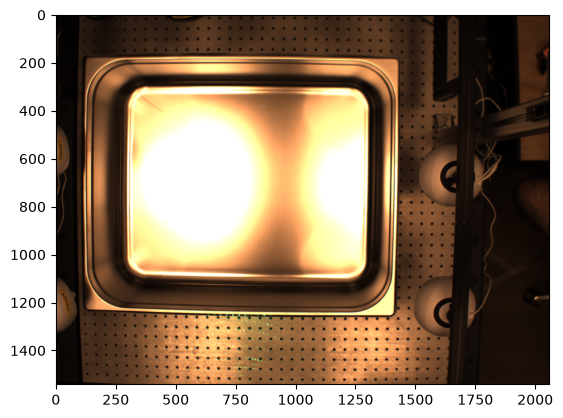

In [13]:
color_img, raw_img = capture_overhead(overhead_cam)
plt.imshow(color_img)

# 3. Setup Laser Camera

## Init Laser Camera

In [14]:
class MikrotronCamera(object):

    def __init__(self, info_field=False, ):
        self.gentl   = EGenTL()
        self.grabber = EGrabber(self.gentl)
        # self.grabber.remote.set("CxpLinkConfiguration", "CXP12_X4")
        self.grabber.stream.set('BufferPartCount', 1)
        self.update_size()
        self.grabber.realloc_buffers(20)
        #self.grabber.start()

        self.info_field = info_field
        if self.info_field:
            self.grabber.remote.set("InfoFieldTimeStampEnable", True)
            self.grabber.remote.set("InfoFieldFrameCounterEnable", True)
            self.grabber.remote.set("InfoFieldRoiEnable", True)

    # def set_buffer_part_count(self, buffer_count):
    #     self.grabber.stream.set('BufferPartCount', buffer_count)
    #     self.grabber.realloc_buffers(20)

    def set_buffer_part_count(self, buffer_count):
        self.grabber.stop()
        self.grabber.stream.set('BufferPartCount', buffer_count)
        self.grabber.realloc_buffers(20)
        self.grabber.start()

    def get_exposure(self):
        return self.grabber.remote.get("ExposureTime")

    def set_exposure(self, exposure_value):
        self.grabber.remote.set("ExposureTime", exposure_value)

    def get_frame_rate(self):
        return self.grabber.remote.get("AcquisitionFrameRate")

    def set_frame_rate(self, frame_rate):
        self.grabber.remote.set("AcquisitionFrameRate", frame_rate)

    def get_max_frame_rate(self):
        return self.grabber.remote.get("AcquisitionFrameRateMax")

    def get_acquisition_mode(self):
        return self.grabber.remote.get("AcquisitionMode")

    def set_gain(self, gain_value):
        self.grabber.remote.set("Gain", gain_value)

    def start_acquisition(self):
        self.grabber.remote.set("AcquisitionMode", "Continuous")
        self.grabber.remote.execute("AcquisitionStart")
        while not self.grabber.remote.done("AcquisitionStart"):
            pass

    def stop_acquisition(self):
        self.grabber.remote.execute("AcquisitionStop")
        while not self.grabber.remote.done("AcquisitionStop"):
            pass

    def reset_buffer(self):
        self.update_size()
        self.grabber.stop()
        self.grabber.realloc_buffers(20)
        self.grabber.start()

    # ---------- global ROI -----------

    def get_global_roi(self):
        x = self.grabber.remote.get("OffsetX")
        w = self.grabber.remote.get("Width")
        y = self.grabber.remote.get("OffsetY")
        h = self.grabber.remote.get("Height")
        return (x, y, w, h)

    def reset_global_roi(self):
        self.grabber.stop()
        self.grabber.remote.set("MultiROILUTModeEn", False)
        self.grabber.remote.set("OffsetX", 0)
        self.grabber.remote.set("OffsetY", 0)
        self.grabber.remote.set("Width", 1920)
        self.grabber.remote.set("Height", 1080)
        self.reset_buffer()
        self.grabber.start()

    def set_global_roi(self, x, y, w, h):
        x1, y1, x2, y2 = x, y, x + w, y + h
        if w < 128 or w % 16 != 0 or w > 1920:
            raise Exception("Set Width has to be greater than 128 px, and incremented by 16")
        #if h < 8 or h % 4 != 0 or h > 1080:
        #    raise Exception("Set Height has to be greater than 8 px, and incremented by 8")
        if x % 16 != 0:
            raise Exception("Set OffsetX has to be greater than 16 px, and incremented by 16")
        if y % 4 != 0:
            raise Exception("Set OffsetY has to be greater than 8 px, and incremented by 4")

        if x1 < 0 or y1 < 0 or x2 > 1920 or y2 > 1080:
            raise Exception("ROI out of sensor limits!")

        ## this order matters, set the height to a smaller value first
        ## then it lets you set the offset
        self.grabber.remote.set("Width", w)
        self.grabber.remote.set("Height", h)
        self.grabber.remote.set("OffsetX", x)
        self.grabber.remote.set("OffsetY", y)

        self.reset_buffer()

    def set_global_roi_noy(self, x, y, w, h):
        x1, y1, x2, y2 = x, y, x + w, y + h
        if w < 128 or w % 16 != 0 or w > 1920:
            raise Exception("Set Width has to be greater than 128 px, and incremented by 16")
        #if h < 8 or h % 4 != 0 or h > 1080:
        #    raise Exception("Set Height has to be greater than 8 px, and incremented by 8")
        if x % 16 != 0:
            raise Exception("Set OffsetX has to be greater than 16 px, and incremented by 16")
        if y % 4 != 0:
            raise Exception("Set OffsetY has to be greater than 8 px, and incremented by 4")

        if x1 < 0 or y1 < 0 or x2 > 1920 or y2 > 1080:
            raise Exception("ROI out of sensor limits!")

        ## this order matters, set the height to a smaller value first
        ## then it lets you set the offset
        self.grabber.remote.set("Width", w)
        self.grabber.remote.set("Height", h)
        self.grabber.remote.set("OffsetX", x)

        self.reset_buffer()

    # ---------- rows -----------

    def set_rows(self, row_idxs):

        self.grabber.remote.set("MultiROILUTModeEn", False)
        H = len(row_idxs) * 2
        if H % 4 != 0:
            raise Exception("Set H is not a multiple of 4")

        for i, idx in enumerate(row_idxs):
            self.grabber.remote.set("MultiROILUTIndex", i)
            self.grabber.remote.set("MultiROILUTValue", int(idx))

        self.grabber.remote.set("Height", H)
        self.grabber.remote.set("MultiROILUTModeEn", True)
        self.reset_buffer()

    '''
    def set_rows_with_index(self, indexed_rows):

        self.grabber.remote.set("MultiROILUTModeEn", False)

        for idx, row in indexed_rows:
            self.grabber.remote.set("MultiROILUTIndex", idx)
            self.grabber.remote.set("MultiROILUTValue", int(row))

        self.grabber.remote.set("MultiROILUTModeEn", True)
        self.reset_buffer()

    def change_row(self, register_idx, row):
        self.grabber.remote.set("MultiROILUTIndex", register_idx)
        self.grabber.remote.set("MultiROILUTValue", row)

    def unset_rows(self):
        self.grabber.remote.set("MultiROILUTModeEn", False)
        for idx, row in enumerate(range(0, 540)):
            self.grabber.remote.set("MultiROILUTIndex", idx)
            self.grabber.remote.set("MultiROILUTIndex", 0)

        self.grabber.remote.set("Height", 1080)
        self.update_size()
    '''

    def update_size(self):
        self.w = self.grabber.stream.get('Width')
        self.h = self.grabber.stream.get('Height')

    def get_im_size(self):
        return self.w, self.h

def get_max_possible_exposure(fps):
    exp = (1000.0/fps) * 1000
    exp = int(exp) - 1
    return exp

'''New capture functions'''
class CaptureFrameThread2(Thread):
    def __init__(self, cam, N_frames, IMG_H, IMG_W):
        super(CaptureFrameThread2, self).__init__()
        self.cam      = cam
        self.frames_per_buffer = cam.grabber.stream.get('BufferPartCount')
        self.N_frames = int(np.ceil(N_frames/self.frames_per_buffer))
        self.w = cam.grabber.stream.get('Width')
        self.h = cam.grabber.stream.get('Height')
        self.h_roi = cam.get_global_roi()[-1]
        self.frames   = np.empty((self.N_frames, self.h, self.w), dtype=np.uint8)

    def __ptr_to_ndarray(self, ptr, w, size):
        data = ct.cast(ptr, ct.POINTER(ct.c_ubyte * size)).contents
        c = 1
        return np.frombuffer(data, count=size, dtype=np.uint8).reshape((-1, w))

    def run(self):
        for i in range(self.N_frames):
            with Buffer(self.cam.grabber, timeout=5000) as buffer:
                buffer_ptr = buffer.get_info(BUFFER_INFO_BASE, INFO_DATATYPE_PTR)
                image_size = buffer.get_info(BUFFER_INFO_CUSTOM_PART_SIZE, INFO_DATATYPE_SIZET)
                delivered  = buffer.get_info(BUFFER_INFO_CUSTOM_NUM_DELIVERED_PARTS, INFO_DATATYPE_SIZET)
                proc = 0
                while proc < delivered:
                    imagePtr = buffer_ptr + proc * image_size
                    img = self.__ptr_to_ndarray(imagePtr, self.cam.w, image_size)
                    self.frames[i,proc*self.h_roi:(proc+1)*self.h_roi] = img.copy()
                    proc = proc + 1
    def read(self):
        video = self.frames.reshape(self.N_frames * self.frames_per_buffer, self.h_roi, self.w)
        return video, None

class CaptureFrameThread(Thread):
    def __init__(self, cam, N_frames, IMG_H, IMG_W, copy=True):
        super(CaptureFrameThread, self).__init__()
        self.cam = cam
        self.N_frames = N_frames
        self.copy = copy
        self.frames = np.empty((N_frames, IMG_H, IMG_W), dtype=np.uint8)
        self.timestamps = np.empty((N_frames,), dtype=np.int64)
        self.frame_counter = 0

    def __ptr_to_ndarray(self, ptr, w, size):
        data = ct.cast(ptr, ct.POINTER(ct.c_ubyte * size)).contents
        c = 1
        return np.frombuffer(data, count=size, dtype=np.uint8).reshape((-1, w))

    def run(self):
        for i in range(self.N_frames):
            with Buffer(self.cam.grabber, timeout=500) as buffer:
                buffer_ptr = buffer.get_info(BUFFER_INFO_BASE, INFO_DATATYPE_PTR)
                image_size = buffer.get_info(BUFFER_INFO_CUSTOM_PART_SIZE, INFO_DATATYPE_SIZET)
                img = self.__ptr_to_ndarray(buffer_ptr, self.cam.w, image_size)
                ts = time.perf_counter_ns() // 1000000
                self.frames[i] = img.copy()
                self.timestamps[i] = ts
                self.frame_counter = (self.frame_counter + 1) % 256
    def read(self):
        return self.frames, self.timestamps

def capture_N_frames(cam, N_frames, IMG_H, IMG_W, dtype=np.uint8):
    cam.grabber.flush_buffers()
    cam.grabber.start()
    thread = CaptureFrameThread2(cam, N_frames, IMG_H, IMG_W)
    thread.start()
    thread.join()
    frames, timestamps = thread.read()
    cam.grabber.stop()
    cam.grabber.flush_buffers()
    return frames, timestamps

def save_data(all_data, N, fps, flag="custom_rows", prefix="frame", unshuffle=False, row_manip=None):
    os.makedirs(f"output/{flag}_{fps}", exist_ok=True)
    for i in range(N):
        img = all_data[i, :, :]
        if unshuffle:
            img = row_manip.unshuffle_camera_rows(img)
        img = cv2.cvtColor(img, cv2.COLOR_BayerGRBG2BGR)
        cv2.imwrite(f"output/{flag}_{fps}/{prefix}.{i}.jpg", img)
        # exit()

def create_hann_window(image_shape,margin,dtype =cv2.CV_32F):
    def pad_image(image, h_pad, v_pad):
        padded_image = cv2.copyMakeBorder(image, v_pad, v_pad, h_pad, h_pad, cv2.BORDER_CONSTANT, value=[0, 0, 0])
        return padded_image

    h,w  = image_shape
    hannW = cv2.createHanningWindow((w - 2*margin, h - 2*margin), dtype)
    hannW = pad_image(hannW,margin,margin)
    return hannW

def stretch_contrast(image,minmax=None):
    if minmax is None:
        min_val = np.min(image)
        max_val = np.max(image)
    else:
        min_val,max_val = minmax
    stretched = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    return stretched

def select_rectangle(image):
    rect_coords = cv2.selectROI("Image", image, fromCenter=False, showCrosshair=True)

    # Close the window
    cv2.destroyAllWindows()

    # Return the rectangle image_showcoordinates
    return rect_coords

In [15]:
cam = MikrotronCamera(info_field=False)
run_opt['cam_params'] = {}

## Preview Laser Camera

In [16]:
class FramePreviewThread(Thread):
    def __init__(self, cam, show_full_frame=True):

        super(FramePreviewThread, self).__init__()
        self.cam = cam
        self.running = True

        self.w = cam.grabber.stream.get('Width')
        self.h = cam.grabber.stream.get('Height')
        self.h_roi = cam.get_global_roi()[-1]
        self.show_full_frame = show_full_frame

        if self.show_full_frame:
            self.frame = np.zeros((self.h,self.w,1),dtype='uint8')
        else:
            self.frame = np.zeros((self.h_roi,self.w,1),dtype='uint8')
        self.frame_counter = 0

    def __ptr_to_ndarray(self, ptr, w, size):
        data = ct.cast(ptr, ct.POINTER(ct.c_ubyte * size)).contents
        c = 1
        return np.frombuffer(data, count=size, dtype=np.uint8).reshape((-1,w))

    def run(self):
        while self.running:
            with Buffer(self.cam.grabber, timeout=5000) as buffer:
                buffer_ptr = buffer.get_info(BUFFER_INFO_BASE, INFO_DATATYPE_PTR)
                image_size = buffer.get_info(BUFFER_INFO_CUSTOM_PART_SIZE, INFO_DATATYPE_SIZET)
                delivered  = buffer.get_info(BUFFER_INFO_CUSTOM_NUM_DELIVERED_PARTS, INFO_DATATYPE_SIZET)
                proc = 0
                while proc < delivered:
                    imagePtr = buffer_ptr + proc * image_size
                    img = self.__ptr_to_ndarray(imagePtr, self.cam.w, image_size)
                    if self.show_full_frame:
                        self.frame[proc*self.h_roi:(proc+1)*self.h_roi,:,0] = img.copy()
                    else:
                        self.frame = img
                    proc = proc + 1
                    self.frame_counter =  (self.frame_counter + 1) % 256

    def read(self):
        return self.frame, self.frame_counter

    def stop(self):
        self.running = False

show_full_frame = 0

def preview_camera(cam, resize_factor = 1, gamma_val=2, is_strech_contrast=0,use_crop = None,
                   show_full_frame=True):

    try:
        #cam.stop_acquisition()
        cam.grabber.start()
        #cam.start_acquisition()
        thread = FramePreviewThread(cam,show_full_frame=show_full_frame)
        thread.start()
        cv2.namedWindow("frame")

        # Get the window handle for the OpenCV window
        hwnd = ctypes.windll.user32.FindWindowW(None, "frame")

        prev_time = time.time()
        fps = 0

        while(True):

            frame,thread_counter = thread.read()

            frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)

            if use_crop is not None:
                frame = frame[:,use_crop[0]:use_crop[1]]

            if resize_factor!=1:
                frame = cv2.resize(frame,None,fx = resize_factor, fy = resize_factor)

            # Calculate FPS
            #curr_time = time.time()
            #time_diff = curr_time - prev_time
            #fps = 1 / (time_diff + 1e-12)
            #prev_time = curr_time

            # Add FPS to the frame

            if is_strech_contrast:
                frame_show = stretch_contrast(frame)
            else:
                frame_show = frame

            cv2.putText(frame,'cam',(30,30), FONT, 0.75,(255,255,255),2,cv2.LINE_AA)

            #fps_text = f'FPS: {fps:.2f}'
            #cv2.putText(frame_show, fps_text, (30, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2, cv2.LINE_AA)


            cv2.imshow("frame",frame_show)

            # Bring the window to the front
            ctypes.windll.user32.SetWindowPos(hwnd, HWND_TOPMOST, 0, 0, 0, 0, SWP_NOMOVE | SWP_NOSIZE)

            key = cv2.waitKeyEx(1)
            if key==13:
                break
            elif key==32: #space
                pass
            if key==40: # "( key"
                gamma_val-= 0.1
            if key==41: # ") key"
                gamma_val+= 0.1

    except Exception:
        traceback.print_exc()
        print('Closing camera thread.')

    # cleanup
    cv2.destroyAllWindows()
    thread.stop()
    thread.join()
    #cam.stop_acquisition()
    cam.grabber.stop()
    cam.grabber.flush_buffers()

The preview appears in a popup window. Click enter to exit.

In [17]:
preview_camera(cam,resize_factor=1,gamma_val=2.5,use_crop = None,show_full_frame=show_full_frame,is_strech_contrast=1)

In [18]:
cam.reset_global_roi()
print('We reset the ROIs')

We reset the ROIs


## Set low frame rate for calibration

In [19]:
run_opt['cam_params']['camera_FPS'] = CALIBRATION_FPS
run_opt['cam_params']['exposure']   = CALIBRATION_EXPOSURE
run_opt['cam_params']['gain']   = CALIBRATION_GAIN

cam.set_frame_rate(run_opt['cam_params']['camera_FPS'])
cam.set_exposure(run_opt['cam_params']['exposure'])
cam.set_gain(run_opt['cam_params']['gain'])

print(f'ROI = {cam.get_global_roi()}')
print('Image height = {:} [px]'.format(cam.grabber.stream.get('Height')))
print(f'frame rate  = {cam.get_frame_rate()} [FPS]')
print(f'exposure  = {cam.get_exposure()} [us]')
print(f'max frame rate = {cam.get_max_frame_rate()} [Hz]')

cam.set_buffer_part_count(1)
if 1:
    run_opt['cam_params']['get_global_roi'] = cam.get_global_roi()
    run_opt['cam_params']['get_frame_rate'] = cam.get_frame_rate()
    run_opt['cam_params']['get_max_frame_rate'] = cam.get_max_frame_rate()
    run_opt['cam_params']['get_exposure'] = cam.get_exposure()

ROI = (0, 0, 1920, 1080)
Image height = 1080 [px]
frame rate  = 500 [FPS]
exposure  = 60 [us]
max frame rate = 1123 [Hz]


## Reset ROIs

At this point, the laser should be turned on!

## Set the ROIs

In [20]:
run_opt_multiROIs = {}
run_opt_multiROIs['N_ROIs'] = N_ROI_ROWS

[(920, 96), (894, 199), (902, 305), (903, 394), (913, 490), (911, 609), (910, 700), (529, 794), (516, 892), (519, 995)]
[(443, 985), (1474, 955)]


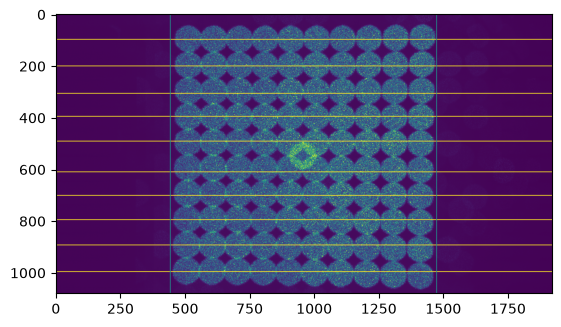

In [21]:
if RESET_ROIS:

    frame_recording, times = capture_N_frames(cam, 10, *cam.get_im_size()[::-1]) # todo: should this 10 also be N_ROIs?

    def select_points_horiz(event, x, y, flags, param):
        global points, num_points

        # On left mouse button click
        if event == cv2.EVENT_LBUTTONDOWN:
            # Store the point
            points.append((x, y))

            # Draw a horizontal line across the row of the clicked point
            cv2.line(image, (0, y), (image.shape[1], y), 255, 2)
            cv2.imshow("Image", image)
            num_points += 1

            # If we have reached the desired number of points, stop
            if num_points >= param:
                cv2.setMouseCallback("Image", lambda *args : None)  # Disable further callbacks
                cv2.destroyAllWindows()

    def select_points_vert(event, x, y, flags, param):
        global points, num_points

        # On left mouse button click
        if event == cv2.EVENT_LBUTTONDOWN:
            # Store the point
            points.append((x, y))

            # Draw a horizontal line across the row of the clicked point
            cv2.line(image, (x, 0), (x,image.shape[0]), 255, 2)
            cv2.imshow("Image", image)
            num_points += 1

            # If we have reached the desired number of points, stop
            if num_points >= param:
                cv2.setMouseCallback("Image", lambda *args : None)  # Disable further callbacks
                cv2.destroyAllWindows()

    def get_points_from_image(image_np, N,select_points_fun):
        global image, points, num_points
        points = []  # Reset points list
        num_points = 0  # Reset point counter
        image = image_np.copy()  # Work on a copy of the image

        # Display the image and set the mouse callback function
        cv2.imshow("Image", image)
        cv2.setMouseCallback("Image", select_points_fun, param=N)

        # This ensures the window can update properly
        while True:
            # Wait for a key press
            key = cv2.waitKey(1) & 0xFF
            # If all points are selected or the user presses the 'q' key, exit loop
            if num_points >= N or key == ord('q'):
                break

        cv2.destroyAllWindows()

        return points

    image                = stretch_contrast(frame_recording[-1].copy())

    points = []
    num_points = 0
    selected_points      = get_points_from_image(image, run_opt_multiROIs['N_ROIs'],select_points_horiz)

    points = []
    num_points = 0
    selected_points_crop = get_points_from_image(image, 2, select_points_vert)

    print(selected_points)
    print(selected_points_crop)

    for x,y in selected_points:
        cv2.line(image, (0, y), (image.shape[1], y), 255, 2)

    for x,y in selected_points_crop:
        cv2.line(image, (x, 0), (x,image.shape[0]), 128, 2)

    plt.figure()
    plt.imshow(image)



## Compute ROIs

In [22]:
run_opt_multiROIs['ROI_height']         = ROI_ROW_HEIGHT
run_opt_multiROIs['total_image_height'] = run_opt_multiROIs['N_ROIs'] * run_opt_multiROIs['ROI_height']
print(ROI_ROW_HEIGHT)

30


In [23]:
if RESET_ROIS:

    # get ROI list
    ROI_list   = []
    ROI_values = []
    for x,y in selected_points:
        ROI_start = (y - run_opt_multiROIs['ROI_height']//2)
        ROI_start += ROI_start % 2
        ROI_end   = ROI_start + run_opt_multiROIs['ROI_height']
        ROI_list.append((ROI_start,ROI_end))
        ROI_vals  = np.arange(ROI_start,ROI_end,2)//2
        ROI_values.append(ROI_vals)

    ROI_values_single_list = np.asarray(ROI_values).flatten()
    print(f'ROIs list:\n{ROI_list}'); print('')
    print(f'values per ROI:\n{ROI_values}'); print('')
    print(f'all values list:\n{ROI_values_single_list}')
    print('Total image height = {}'.format(run_opt_multiROIs['total_image_height']))
    print('Max FPS = {} Hz'.format(int(1080/run_opt_multiROIs['total_image_height'] * 2247 * (1000/1024)**4)))

    OffsetX = int(np.round(selected_points_crop[0][0]/16)*16)
    Width   =  selected_points_crop[1][0] - OffsetX
    Width   =  int(np.round(Width/16)*16)

    run_opt_multiROIs['global_ROI'] = (OffsetX, 0,Width,run_opt_multiROIs['total_image_height'])
    print(run_opt_multiROIs['global_ROI'])

    # Save the row positions for later use (before they get overwritten)
    run_opt_multiROIs['selected_row_points'] = selected_points.copy()
    run_opt_multiROIs['ROI_list'] = ROI_list

ROIs list:
[(82, 112), (184, 214), (290, 320), (380, 410), (476, 506), (594, 624), (686, 716), (780, 810), (878, 908), (980, 1010)]

values per ROI:
[array([41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55]), array([ 92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106]), array([145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,
       158, 159]), array([190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202,
       203, 204]), array([238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250,
       251, 252]), array([297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309,
       310, 311]), array([343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355,
       356, 357]), array([390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402,
       403, 404]), array([439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451,
       452, 453]), array([490, 491, 492, 493, 494, 495, 496, 497, 498, 4

In [24]:

cam.set_rows(ROI_values_single_list)

To exit the preview, click enter

In [25]:
preview_camera(cam,resize_factor=1,gamma_val=2.5,use_crop = None,show_full_frame=show_full_frame,is_strech_contrast=1)

## Horizontally Crop the ROI Rows


For some reason, you have to preview the ROI (which we do above) before horozontally cropping it otherwise the crop will fail.

In [26]:
if RESET_ROIS:
    cam.set_global_roi_noy(*run_opt_multiROIs['global_ROI'])

    print(f'ROI = {cam.get_global_roi()}')
    print(f'frame rate  = {cam.get_frame_rate()} [FPS]')
    print(f'exposure  = {cam.get_exposure()} [us]')
    print(f'max frame rate = {cam.get_max_frame_rate()} [Hz]')

ROI = (448, 0, 1024, 300)
frame rate  = 500 [FPS]
exposure  = 60 [us]
max frame rate = 7501 [Hz]


In [27]:
preview_camera(cam,resize_factor=1,gamma_val=2.5,use_crop = None,show_full_frame=show_full_frame,is_strech_contrast=1)

## Set ROI Columns

In [28]:
run_opt_recovery['N_vert_ROIs']    = N_ROI_COLUMNS

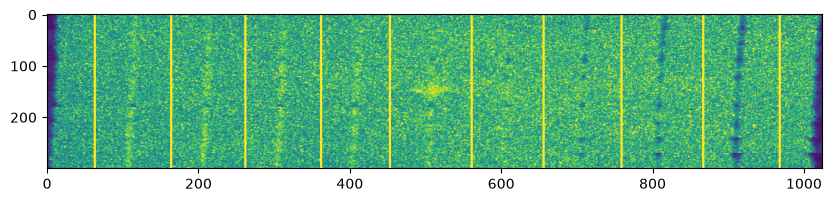

In [31]:
if RESET_ROIS:
    from utils.recover_core_lib import *

    points = []
    num_points = 0

    frame_recording, times = capture_N_frames(cam, 10, *cam.get_im_size()[::-1])
    raw_frame = frame_recording[-1].copy().astype(np.float32)

    # 2. Apply Log Transform: I_out = log(1 + I_in)
    image_log = np.log1p(raw_frame)

    # 3. Normalize the log image to 0-255 range for display (uint8)
    image = cv2.normalize(image_log, None, 0, 255, cv2.NORM_MINMAX)
    image = image.astype(np.uint8)

    min_height = 20
    h, w = image.shape
    if h < min_height:
        repeat_factor = math.ceil(min_height / h)
        image = np.repeat(image, repeat_factor, axis=0)

    # Rename to avoid overwriting the row points
    selected_column_points = get_points_from_image(image, run_opt_recovery['N_vert_ROIs'])

    for x, y in selected_column_points:
        cv2.line(image, (x, 0), (x, image.shape[0]), 255, 2)

    plt.figure(figsize=(10, 2))
    plt.imshow(image, aspect='auto')
    plt.show()

In [32]:
if 'run_opt_multiROIs' in run_opt:
    run_opt_multiROIs = run_opt['run_opt_multiROIs']
else: # runs in manual mode
    print('running manually')
    # run_opt_multiROIs = {}
    run_opt_multiROIs['N_ROIs'] = N_ROI_ROWS
    run_opt_multiROIs['ROI_height'] = ROI_ROW_HEIGHT

print(run_opt_multiROIs)

running manually
{'N_ROIs': 10, 'ROI_height': 30, 'total_image_height': 300, 'global_ROI': (448, 0, 1024, 300), 'selected_row_points': [(920, 96), (894, 199), (902, 305), (903, 394), (913, 490), (911, 609), (910, 700), (529, 794), (516, 892), (519, 995)], 'ROI_list': [(82, 112), (184, 214), (290, 320), (380, 410), (476, 506), (594, 624), (686, 716), (780, 810), (878, 908), (980, 1010)]}


## Final ROI Preview

In [33]:
import matplotlib.patches as patches

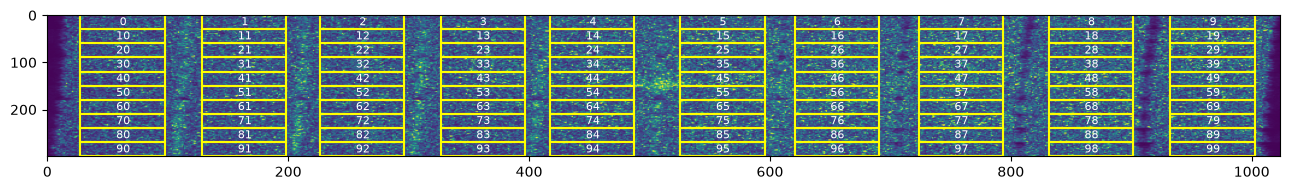

In [34]:
run_opt_recovery['N_vert_ROI_width'] = ROI_COLUMN_WIDTH

if RESET_ROIS:
    ROIs = []
    for row in range(run_opt_multiROIs['N_ROIs']):
        for col in range(run_opt_recovery['N_vert_ROIs']):
            x = selected_column_points[col][0] - run_opt_recovery['N_vert_ROI_width'] // 2
            y = row * run_opt_multiROIs['ROI_height']
            w = run_opt_recovery['N_vert_ROI_width']
            h = run_opt_multiROIs['ROI_height']
            ROIs.append((x, y, w, h))

    # manual change
    if 0:
        ROIs = ROIs[6:]
        ROIs.append((385 - run_opt_recovery['N_vert_ROI_width'] // 2, 0, w, h))

    run_opt_multiROIs['ROIs'] = ROIs

    # 1. Get the clean image (Do not draw cv2 rectangles on it)
    frame_show = stretch_contrast(frame_recording[5].copy())

    # 2. Setup the plot
    fig, ax = plt.subplots(figsize=(13, 2))
    ax.imshow(frame_show, aspect='auto')

    # 3. Add Vector Rectangles and Text on top
    for i, (x, y, w, h) in enumerate(run_opt_multiROIs['ROIs']):
        # Create the rectangle patch
        # (x - 0.5, y - 0.5) aligns the border exactly around the pixels
        rect = patches.Rectangle((x - 0.5, y - 0.5), w, h,
                                linewidth=1.5,      # Fixed screen width (remains thin)
                                edgecolor='yellow', # Color
                                facecolor='none')   # Transparent center

        # Add the rectangle to the plot
        ax.add_patch(rect)

        # Add the text label
        # Calculating center for the text position
        center_x = x + w / 2
        center_y = y + h / 2
        ax.text(center_x, center_y, str(i),
                color='white', fontsize=8,
                ha='center', va='center')

    plt.tight_layout()
    plt.show()

## Set high frame rate for capturing

In [35]:
run_opt['cam_params']['camera_FPS'] = FPS
run_opt['cam_params']['exposure']   = EXPOSURE # how much light we let in
run_opt['cam_params']['gain']       = GAIN # amplify the elctrical signal caused by the photons

cam.set_frame_rate(run_opt['cam_params']['camera_FPS'])
cam.set_exposure(run_opt['cam_params']['exposure'])
cam.set_gain(run_opt['cam_params']['gain'])

print(f'ROI = {cam.get_global_roi()}')
print('Image height = {:} [px]'.format(cam.grabber.stream.get('Height')))
print(f'frame rate  = {cam.get_frame_rate()} [FPS]')
print(f'exposure  = {cam.get_exposure()} [us]')
print(f'max frame rate = {cam.get_max_frame_rate()} [Hz]')

if 1:
    run_opt['cam_params']['get_global_roi'] = cam.get_global_roi()
    run_opt['cam_params']['get_frame_rate'] = cam.get_frame_rate()
    run_opt['cam_params']['get_max_frame_rate'] = cam.get_max_frame_rate()
    run_opt['cam_params']['get_exposure'] = cam.get_exposure()

ROI = (448, 0, 1024, 300)
Image height = 300 [px]
frame rate  = 2500 [FPS]
exposure  = 60 [us]
max frame rate = 7501 [Hz]


In [36]:
# makes it faster to capture/send frames
cam.set_buffer_part_count(BUFFER_PART_COUNT)
print(f'buffer count = {BUFFER_PART_COUNT}')

buffer count = 1625


# 4. Setup Speakers

In [37]:
# add repo root (for utils) and src/data (for image, vibrate) to sys.path
import sys
from pathlib import Path
for p in (Path.cwd().parent, Path.cwd() / 'data'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
from utils.io_utils import load

In [38]:
# List devices
# our devices are Line Out (UltraLite-mk5) Windows WASAPI
# we do not use Windows DirectSound
print(sd.query_devices())
print(sd.query_hostapis())  # confirm ASIO is listed #todo: why??

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Line In 7-8 (UltraLite-mk5), MME (2 in, 0 out)
   2 Line In 5-6 (UltraLite-mk5), MME (2 in, 0 out)
   3 Mic/Line/Inst In 1-2 (UltraLite, MME (2 in, 0 out)
   4 Line In 3-4 (UltraLite-mk5), MME (2 in, 0 out)
   5 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  6 Main Out 1-2 (UltraLite-mk5), MME (0 in, 2 out)
   7 Realtek Digital Output (Realtek, MME (0 in, 2 out)
   8 Phones Out 1-2 (UltraLite-mk5), MME (0 in, 2 out)
   9 Line Out 7-8 (UltraLite-mk5), MME (0 in, 2 out)
  10 PL2792Q (NVIDIA High Definition, MME (0 in, 2 out)
  11 Line Out 5-6 (UltraLite-mk5), MME (0 in, 2 out)
  12 Line Out 9-10 (UltraLite-mk5), MME (0 in, 2 out)
  13 Line Out 3-4 (UltraLite-mk5), MME (0 in, 2 out)
  14 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
  15 Line In 7-8 (UltraLite-mk5), Windows DirectSound (2 in, 0 out)
  16 Line In 5-6 (UltraLite-mk5), Windows DirectSound (2 in, 0 out)
  17 Mic/Line/Inst In 1-2 (UltraLite-mk

In [39]:
def find_device(name_substring, hostapi_name="Windows WASAPI"):
    hostapis = sd.query_hostapis()
    target_hostapi = next(i for i, h in enumerate(hostapis) if h['name'] == hostapi_name)
    for idx, dev in enumerate(sd.query_devices()):
        if (dev['hostapi'] == target_hostapi
            and name_substring in dev['name']
            and dev['max_output_channels'] > 0):
            return idx
    raise ValueError(f"No output device matching {name_substring!r}")

In [40]:
_main   = find_device("Main Out 1-2")
_line34 = find_device("Line Out 3-4")
_line56 = find_device("Line Out 5-6")
_line78 = find_device("Line Out 7-8")
_line910 = find_device("Line Out 9-10")
_phones = find_device("Phones Out 1-2")

SPEAKERS = {
    1:  (_main,   0, False),
    2:  (_main,   1, False),
    3:  (_line34, 1, False),
    4:  (_line34, 0, False),
    5:  (_line56, 0, False),
    6:  (_line56, 1, False),
    7:  (_line78, 0, False),
    8:  (_line78, 1, False),
}

SPEAKERS

{1: (35, 0, False),
 2: (35, 1, False),
 3: (34, 1, False),
 4: (34, 0, False),
 5: (32, 0, False),
 6: (32, 1, False),
 7: (30, 0, False),
 8: (30, 1, False)}

In [41]:
device_info = sd.query_devices(list(SPEAKERS.values())[0][0])
SAMPLE_RATE = int(device_info['default_samplerate'])
print(f"Using sample rate: {SAMPLE_RATE}")

Using sample rate: 44100


In [42]:
_active_streams = []  # streams from the last non-blocking play_audio call; closed at the start of the next one

def play_audio(audio_input, speakers, wait=False):
    if isinstance(audio_input, (str, Path)):
        samples, _ = load(audio_input)  # (samples, sample_rate)
        audio = samples.astype(np.float32) / np.iinfo(samples.dtype).max
        if audio.ndim > 1: audio = audio.mean(axis=1)
    # if isinstance(audio_input, str):
    #     audio, _ = sf.read(audio_input, dtype="float32", always_2d=True)
    #     audio = audio.mean(axis=1)
    else:
        audio = audio_input

    if not isinstance(speakers, (list, tuple)):
        speakers = [speakers]

    # Group by device, build a stereo buffer per device
    device_bufs = {}
    for speaker in speakers:
        device_idx, channel_idx, is_mono = SPEAKERS[speaker]
        if device_idx not in device_bufs:
            device_bufs[device_idx] = np.zeros((len(audio), 2), dtype=np.float32)
        if is_mono:
            device_bufs[device_idx][:, 0] = device_bufs[device_idx][:, 1] = audio
        else:
            device_bufs[device_idx][:, channel_idx] = audio

    # close out streams left over from the previous non-blocking call, from this (main) thread —
    # never close a stream from inside its own callback, that deadlocks
    for s in _active_streams: s.close()
    _active_streams.clear()

    # Single device: one sd.play call
    if len(device_bufs) == 1:
        device_idx, buf = next(iter(device_bufs.items()))
        sd.play(buf, samplerate=SAMPLE_RATE, device=device_idx)
        if wait:
            sd.wait()
        return

    # Multiple devices: OutputStream with callbacks - PortAudio handles concurrency, no Python threads
    streams = []
    for device_idx, buf in device_bufs.items():
        pos = [0]
        def callback(outdata, frames, time_info, status, buf=buf, pos=pos):
            remaining = len(buf) - pos[0]
            chunk = min(frames, remaining)
            outdata[:chunk] = buf[pos[0]:pos[0] + chunk]
            if chunk < frames:
                outdata[chunk:] = 0
                raise sd.CallbackStop()
            pos[0] += chunk
        streams.append(sd.OutputStream(samplerate=SAMPLE_RATE, device=device_idx, channels=2, callback=callback))

    _active_streams.extend(streams)  # keep references alive so streams aren't garbage-collected mid-playback
    for s in streams:
        s.start()
    if wait:
        while any(s.active for s in streams):
            time.sleep(0.01)
        for s in streams: s.close()
        _active_streams.clear()

In [43]:
# play from three speakers at once, across different line outs
play_audio(AUDIO_DIR / 'audio.wav', [3,6,7], wait=True)

In [44]:
# play_audio(AUDIO_DIR / 'audio.wav', [1], wait=True)

In [45]:
# # play each speaker one by one
# for speaker in SPEAKERS.keys():
#     print(f'{speaker=}')
#     play_audio(AUDIO_PATH, [speaker])

In [46]:
T_SEC = 1
T_START = 0.1
T_END = 0.1
FS = 44100
F_START = 50
F_END = 1000
n_capture_seconds = (T_SEC + T_START + T_END) + 0.1

audio_dir = Path(rf'C:\Users\eitanturok\good-vibrations\data\audio\chirp_{int(F_START)}_{int(F_END)}_{T_SEC}sec')

# run data/audio.py::main() for real -- generates+saves audio.wav, metadata.jsonl, fft.npz/png,
# spectrogram.npz/png, and the spectrogram.mp4 video, all under audio_dir
args = Namespace(T_sec=T_SEC, T_start=T_START, T_end=T_END, fs=FS, f_start=F_START, f_end=F_END, out_dir=audio_dir)
audio = main(args)

preview((audio_dir / 'audio.wav', FS), 'audio')

Already computed audio in C:\Users\eitanturok\good-vibrations\data\audio\chirp_50_1000_1sec


In [47]:
# import sounddevice as sd, numpy as np, traceback

# sd.stop()                          # abort any stuck default-stream playback
# sd._terminate(); sd._initialize()  # rebuild PortAudio, drop leaked streams — variables untouched

# # quick single-device test straight to hardware (Line Out 3-4)
# idx = next(i for i,d in enumerate(sd.query_devices())
#            if 'Line Out 3-4' in d['name'] and d['max_output_channels']>0 and d['hostapi']==2)
# try:
#     t = np.linspace(0, 1, 22050, False); tone = 0.1*np.sin(2*np.pi*440*t)
#     sd.play(np.column_stack([tone, tone]).astype(np.float32), samplerate=44100, device=34, blocking=True)
#     print('OK — PortAudio healthy again on', idx)
# except Exception:
#     traceback.print_exc()


# 5 Run Experiment

In [84]:
# top left corner is (0, 0)
CROP_PARAMS = {
    'cardboard': {"left": 0.1, "right": 0.7, "top": 0.21, "bottom": 0.78},
    'taped-cardboard': {"left": 0.07, "right": 0.63, "top": 0.05, "bottom": 0.65},
    'wood': {"left": 0.23, "right": 0.55, "top": 0.47, "bottom": 0.8},
    'slat-wood': {"left": 0.2, "right": 0.55, "top": 0.2, "bottom": 0.8},
    'metal': {"left": 0.21, "right": 0.54, "top": 0.66, "bottom": 0.86},
    'shoebox': {"left": 0.21, "right": 0.56, "top": 0.44, "bottom": 0.82},
    'plastic': {"left": 0.24, "right": 0.59, "top": 0.27, "bottom": 0.62},
    'gastronorm': {"left": 0.05, "right": 0.7, "top": 0.1, "bottom": 0.82},
}

PROMPTS = {'cylinder': "Metal circle", 'bullet': 'Metal circle', 'cylinder-bullet-stack': 'Metal circle', 'cube': 'Black cube with straight edges',
           'green-cube': 'Green square', 'purple-cube': 'Purple square', 'red-cube': 'Red cube'}

COLOR_WORDS = ["red", "green", "blue", "yellow", "purple", "orange", "pink", "black", "white", "gray", "brown"]

MIN_FREQ, MAX_FREQ = 50, 1000

# init SAM3 on modal
result = subprocess.run([sys.executable, "-m", "modal", "deploy", "data/segment.py"], capture_output=True, text=True, encoding="utf-8", errors="replace")
segmenter = modal.Cls.from_name("segment", "Segmenter")()
# print(result.stdout,  '\n', result.stderr)
result.check_returncode()

def crop(image: np.ndarray, left: float, right: float, bottom: float, top: float) -> np.ndarray:
    h, w = image.shape[:2]
    
    x1 = int(w * left)
    x2 = int(w * right)
    y1 = int(h * top)
    y2 = int(h * bottom)
    return image[y1:y2, x1:x2]

def plot_overhead(seg_results, crop_overhead, ax=None, box_padding=15):
    if ax is None: fig, ax = plt.subplots(figsize=(16, 6))

    img_h, img_w = crop_overhead.shape[:2]
    ax.imshow(crop_overhead)

    colors = plt.get_cmap("tab10").colors  # 10 distinct, high-contrast colors (cycles if more objects)
    overlay = np.zeros((img_h, img_w, 4)) # create one single image from all objects b/c it is faster to render
    boxes_to_draw = []

    for obj_idx, ((object, n_objects), result) in enumerate(zip(objects.items(), seg_results)):
        color = next((to_rgb(w) for w in COLOR_WORDS if w in object.lower()), colors[obj_idx % len(colors)])
        for i in range(n_objects):
            mask, (x1, y1, x2, y2), score = result["masks"][i], result["boxes"][i], result["scores"][i]
            x1, y1 = max(0, x1 - box_padding), max(0, y1 - box_padding)
            x2, y2 = min(img_w, x2 + box_padding), min(img_h, y2 + box_padding)
            overlay[mask] = (*color, 0.5)  # composited into one array
            boxes_to_draw.append((x1, y1, x2, y2, color, f"{object}-{i} {score*100:.1f}"))

    ax.imshow(overlay)  # single imshow() for all objects, was N separate full-canvas imshow() calls
    for x1, y1, x2, y2, color, text in boxes_to_draw:
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=2))
        ax.text(x1, y1 - 4, text, color=color, fontsize=9, va="bottom", bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1))

    ax.axis("off")

def plot_smask(seg_results, crop_overhead, ax=None):
    if ax is None: fig, ax = plt.subplots(figsize=(16, 6))

    img_h, img_w = crop_overhead.shape[:2]
    ax.imshow(np.zeros((img_h, img_w, 3)))
    colors = plt.get_cmap("tab10").colors

    overlay = np.zeros((img_h, img_w, 4))
    for obj_idx, ((object, n_objects), result) in enumerate(zip(objects.items(), seg_results)):
        color = next((to_rgb(w) for w in COLOR_WORDS if w in object.lower()), colors[obj_idx % len(colors)])
        for i in range(n_objects):
            overlay[result["masks"][i]] = (*color, 0.7)

    ax.imshow(overlay)  # single imshow() instead of one per object
    ax.axis("off")

def plot_coverage(coverage, layout, smask, ax=None):
    if ax is None: fig, ax = plt.subplots(figsize=(16, 6))

    layout_coverage, n_samples = coverage[layout]
    
    if layout != 'empty-box':
        im = ax.imshow(layout_coverage, cmap='Blues')
        ax.figure.colorbar(im, ax=ax, label='coverage')

        # plot the current smask in red
        red = np.zeros((*smask.shape, 4))
        red[smask] = (1, 0, 0, 1)
        ax.imshow(red)
        
    ax.set_title(f'Box Coverage {layout} ({n_samples} samples)')

def plot_shifts(shifts, fps, laser_idx: int | None=None, ax=None):
    if laser_idx == None:
        assert shifts.shape[0] > 1, "to avg the shifts, we need more than 1 laser"
        shifts = shifts.mean(axis=0)
    else:
        # if we have more than one laser, index into it
        if shifts.shape[0] > 1:
            shifts = shifts[laser_idx]
    shifts = shifts.squeeze()

    x_shifts, y_shifts = shifts[:, 0], shifts[:, 1]
    t = np.arange(len(x_shifts)) / fps  # frame index -> seconds

    if ax is None: fig, ax = plt.subplots(figsize=(16, 6))

    ax.plot(t, x_shifts, label='x')
    ax.plot(t, y_shifts, label='y')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Shift (pixels)')
    ax.legend()

    laser_label = f'laser={laser_idx or "avg"}'
    ax.set_title(f'Shifts {laser_label}')

def plot_fft_magnitude(fft, freqs, laser_idx: int | None=None, ax=None):

    if laser_idx == None:
        assert fft.shape[0] > 1, "to avg the shifts, we need more than 1 laser"
        fft = fft.mean(axis=0)
    else:
        # if we have more than one laser, index into it
        if fft.shape[0] > 1:
            fft = fft[laser_idx]
    fft = fft.squeeze()
    
    mag = np.abs(fft)  # (L, F, 2)
    mag_x, mag_y = mag[:, 0], mag[:, 1]

    if ax is None: fig, ax = plt.subplots(figsize=(16, 6))

    ax.plot(freqs, mag_x, label='x')
    ax.plot(freqs, mag_y, label='y')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude')

    laser_label = 'avg over lasers' if laser_idx is None else f'laser={laser_idx}'
    ax.set_title(f'FFT Magnitude {laser_label}')

def compute_fft(shifts: np.ndarray, fps:float, min_freq:float=MIN_FREQ, max_freq:float=MAX_FREQ) -> tuple[np.ndarray, np.ndarray, int]:

    """After taking the fft, drop all the frequencies outside of [lowcut, highcut],
    Input:  (L, T, C)
    Output: (L, F, C)
    """
    n_samples = shifts.shape[1]
    full_fft = np.fft.rfft(shifts, axis=1).astype(np.complex64)
    full_freqs = np.fft.rfftfreq(n_samples, d=1.0 / fps)
    mask = (full_freqs >= min_freq) & (full_freqs <= max_freq)
    return full_fft[:, mask, :], full_freqs[mask], n_samples

def count_dirs(path): return 1 + (sum(1 for path in path.iterdir() if path.is_dir()) if path.exists() else 0)

def make_id(path): return f"{count_dirs(path):06d}"

def get_position_id(positions_file):
    if not positions_file.exists(): 
        positions_file.parent.mkdir(parents=True, exist_ok=True)
        positions_file.touch()
    with open(positions_file, "r", encoding="utf-8") as f:
        line_count = sum(1 for _ in f)
    return line_count + 1

def update_position(file, pos_id, sample_id):
    lines = open(file).read().splitlines() if os.path.exists(file) and os.path.getsize(file) else []
    last, k = json.loads(lines[-1]) if lines else {}, str(pos_id)
    data = {**last, k: last[k] + [sample_id]} if k in last else {k: [sample_id]}
    lines[-1 if k in last else len(lines):] = [json.dumps(data)]
    open(file, "w").write("\n".join(lines) + "\n")

In [217]:
experiment_dir = Path(r'D:/eturok/31_07_2026_gastronorm_exp1')

# create directories, files
base_sample_dir = experiment_dir / 'samples'
base_sample_dir.mkdir(parents=True, exist_ok=True)

positions_file = experiment_dir / "positions.jsonl"
positions_file.touch()

# track the training coverage from diff positions in the box
coverage = {} # layout: (all smasks, n_samples)
for sample_dir in sorted(base_sample_dir.iterdir()):
    if (sample_dir / 'metadata.jsonl').exists() and (sample_dir / 'images/03_smask.npy').exists():
        layout = load_metadata(sample_dir / 'metadata.jsonl')['layout']
        smask = load(sample_dir / 'images/03_smask.npy')
        if layout not in coverage: coverage[layout] = (np.zeros(smask.shape[:2]), 0)
        coverage[layout] = (coverage[layout][0] + smask, 1)

# compute n_frames, n_capture_seconds to record vibrations
audio_samples, audio_fs = load(audio_dir / 'audio.wav')
n_capture_seconds = len(audio_samples) / audio_fs + 0.1 # add 0.1s small buffer
n_frames = int(np.ceil(n_capture_seconds * cam.get_frame_rate()))
# assert n_frames % BUFFER_PART_COUNT == 0, f'{n_frames=} does not divide evenly into {BUFFER_PART_COUNT=} for {audio_dir=}'

# derived params
ROIs = run_opt_multiROIs['ROIs']
cam_h, cam_w = cam.get_im_size()[::-1]

# params I don't touch that often
laser_idx = 55
pclk_batch_size = 256
use_PC = True
segment_scale = 1.0

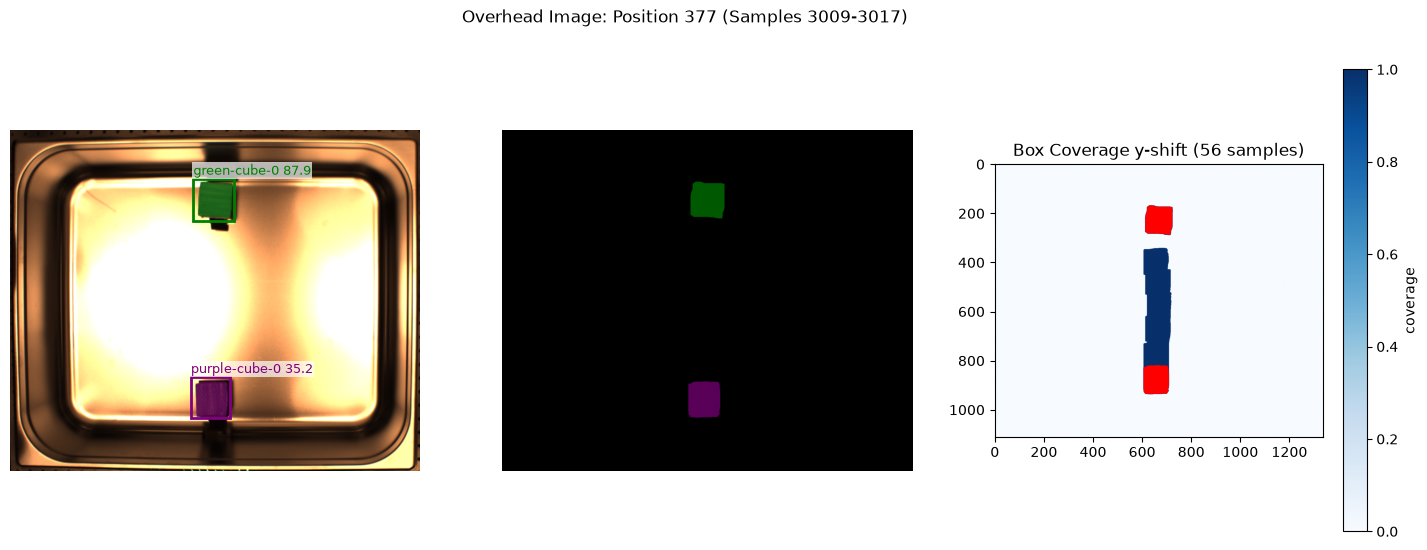

Record: position 377, speaker 1 (sample 003009)


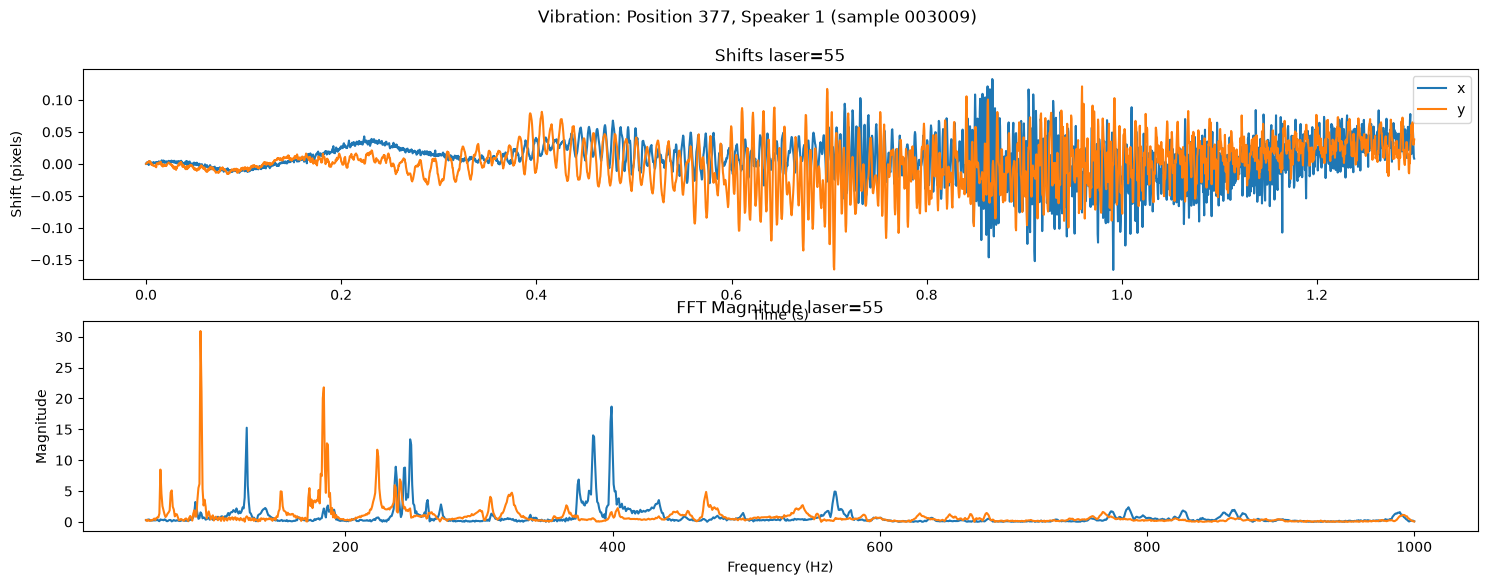

Record: position 377, speaker 2 (sample 003010)
Record: position 377, speaker 3 (sample 003011)
Record: position 377, speaker 4 (sample 003012)
Record: position 377, speaker 5 (sample 003013)
Record: position 377, speaker 6 (sample 003014)
Record: position 377, speaker 7 (sample 003015)
Record: position 377, speaker 8 (sample 003016)


In [452]:
SAVE = True
VIBRATE = True
DEBUG = 1

box = 'gastronorm'

objects = {'purple-cube': 1, 'green-cube': 1}
layout = 'y-shift'
description = f"A metal cube sitting on the floor of an closed {box} box from a bird's eye view."
prompts = [PROMPTS[o] for o in objects]
# if len(objects) == 0: layout, description = "empty-box", f"An empty open {box} box from a bird's eye view." # empty box

# speakers = [1]
speakers = [1, 2, 3, 4, 5, 6, 7, 8]

#***** run experiment *****

# take overhead image + segment objects inside
position_id         = get_position_id(positions_file)
raw_overhead, _     = capture_overhead(overhead_cam)
crop_overhead       = crop(raw_overhead, **CROP_PARAMS[box])
seg_results         = unpack_masks(segmenter.run.remote(to_jpeg_bytes(crop_overhead), prompts, top_k=[freq for freq in objects.values()])) if objects else []
smask               = np.any([mask for result in seg_results for mask in result['masks']], axis=0) if objects else np.zeros(crop_overhead.shape[:2], dtype=bool)
coms                = [[center_of_mass(mask) for mask in result['masks']] for result in seg_results] if objects else [[(-1, -1)]]
avg_com             = np.mean([c for result in coms for c in result], axis=0) if objects else np.array([-1, -1])
coverage[layout]    = (coverage[layout][0] + smask, coverage[layout][1] + len(speakers)) if layout in coverage else (smask, len(speakers))

if DEBUG >= 1:
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    plot_overhead(seg_results, crop_overhead, ax=axs[0])
    plot_smask(seg_results, crop_overhead, ax=axs[1])
    plot_coverage(coverage, layout, smask, ax=axs[2])
    fig.suptitle(f'Overhead Image: Position {position_id} (Samples {int(make_id(base_sample_dir))}-{int(make_id(base_sample_dir))+len(speakers)})')
    plt.show()

if VIBRATE:
    save_threads = []
    for i, speaker in enumerate(speakers):
        sample_id = make_id(base_sample_dir)
        print(f'Record: position {position_id}, speaker {speaker} (sample {sample_id})')
        
        # vibrate the box
        play_audio(audio_dir / 'audio.wav', speaker, wait=False)
        raw_vibrations, _ = capture_N_frames(cam, n_frames, cam_h, cam_w) # (Frame, Height, Width)

        if (DEBUG >=1 and i == 0) or DEBUG >= 2:
            fig, axs = plt.subplots(2, 1, figsize=(18, 6))
            raw_shifts = pclk(raw_vibrations, ROIs, pclk_batch_size, laser_idx=laser_idx, use_PC=use_PC) # (Laser, Frame, 2)
            plot_shifts(raw_shifts, FPS, laser_idx, ax=axs[0])

            fft, freqs, n_samples = compute_fft(raw_shifts, FPS) # (Laser, Freqs, 2), (Freqs), (,)
            plot_fft_magnitude(fft, freqs, laser_idx, ax=axs[1])
            fig.suptitle(f'Vibration: Position {position_id}, Speaker {speaker} (sample {sample_id})')
            plt.show()

        if SAVE:
            # make sample directory
            sample_dir = base_sample_dir / sample_id
            sample_dir.mkdir(parents=True, exist_ok=True)

            # copy audio
            symlink(audio_dir, sample_dir / 'audio')

            # update position
            update_position(positions_file, position_id, sample_id)

            # save metadata
            id_params = dict(sample_id=sample_id, position_id=position_id, speaker=speaker, experiment_dir=experiment_dir, timestamp=datetime.now(timezone.utc).isoformat())
            object_params = dict(box=box, n_objects=sum(objects.values()), objects=objects, layout=layout, description=description, is_empty_box=len(objects) == 0)
            audio_params = dict(audio_dir=audio_dir, audio_fs=audio_fs, min_freq=MIN_FREQ, max_freq=MAX_FREQ)
            segment_params = dict(prompts=prompts, seg_results=seg_results, coms=coms, avg_com=avg_com, segment_scale=segment_scale)
            laser_camera_params = dict(height=cam_h, width=cam_w, n_frames=n_frames, n_capture_seconds=n_capture_seconds, fps=FPS, expose=EXPOSURE, gain=GAIN, buffer_part_count=BUFFER_PART_COUNT)
            laser_params = dict(power=440.9, n_rows=10, n_cols=10, rois=run_opt_multiROIs['ROIs'], run_opt=run_opt, run_opt_multiROIs=run_opt_multiROIs)
            pclk_params = dict(pclk_batch_size=pclk_batch_size, use_PC=use_PC, laser_idx=laser_idx)

            params = id_params | object_params | audio_params | segment_params | laser_camera_params | laser_params | pclk_params
            with open(sample_dir / "metadata.jsonl", "w", encoding="utf-8") as f:
                for key, value in params.items(): f.write(json.dumps({key: value}, default=str) + "\n")

            # save overhead image + smask
            if i == 0:
                save(raw_overhead, sample_dir / 'images/01_raw_overhead.png')
                save(crop_overhead, sample_dir / 'images/02_cropped_overhead.png')
                save(smask, sample_dir / 'images/03_smask.npy')
                save(smask, sample_dir / 'images/03_smask.png')
                first_sample_dir = sample_dir
            else:
                for name in ('01_raw_overhead.png', '02_cropped_overhead.png', '03_smask.npy', '03_smask.png'):
                    symlink(first_sample_dir / 'images' / name, sample_dir / 'images' / name) # faster to symlink then to save
            
            # save vibration in another thread, non-blocking
            t = threading.Thread(target=save, args=(raw_vibrations, sample_dir / 'vibration/01_raw_vibrations.npy'), daemon=True)
            t.start()
            save_threads.append(t)

            # save debug data
            if (DEBUG >=1 and i == 0) or DEBUG >= 2:
                save(raw_shifts, sample_dir / f'vibration/02_raw_shift_laser{laser_idx}.npy')
                save(dict(fft=fft, freqs=freqs, n_samples=n_samples), sample_dir / f'vibration/03_fft_laser{laser_idx}.npz')

    [t.join() for t in save_threads] # block until all threads have saved the vibrations